# Tutorial for Bayesian Optimization, Active Learning and Self-Driving Labs - Notebook 2

> **Note**: This notebook is shared as 'view-only' to ensure proper version control. While you are able to make changes to the code as you wish, these changes will not be saved to the primary version. We highly recommend that you make your own copy which will allow you to save any changes made on your own version. To accomplish this, go to File -> Save a Copy in Drive in the toolbar at the top of the page.
>
> We encourage readers to copy, modify, and use this code for their own projects. We ask that any publications which utilize this tutorial as a starting point to cite the accompanying article. This helps others also find this tutorial and use it as a resource for their own projects.
>
> Maroulis, A., Waynor, D., Gallagher, Q., Patel, R., Tamasi, M., Radford, D. C., Webb, M., & Gormley, A. (2025). A User's Guide to Your First Self-Driving Liquid Handling Lab. ChemRxiv, 2025(1023).
>
> https://doi.org/doi:10.26434/chemrxiv-2025-6ws9m
>
> This is Version 1.0.0, last updated on January 29th, 2026

## Overview

The goal of this tutorial is to walk through the essentials of **Active Learning (AL)** from start to finish, providing both conceptual explanations and hands-on code examples. A basic understanding of **Machine Learning (ML)** is assumed. If you're new to ML, we highly recommend reviewing:

- **A User's Guide to Machine Learning**: https://doi.org/10.1021/acspolymersau.2c00037  
- **Accompanying ML Colab notebook**: https://www.gormleylab.com/MLcolab

### Tutorial Overview

This guide is structured into three main notebooks, each building on the last:

---

#### Tutorial Notebook 1: Principles of Active Learning  
We begin with a simple, two-dimensional example of **Bayesian Optimization (BO)** applied to a black-box function. This notebook introduces the foundational concepts of active learning, including:  
- Data seeding strategies
- Fitting a surrogate model (e.g., Gaussian process, random forest, neural network) to observed data  
- Using different acquisition functions to choose new sampling points

---

>#### Tutorial Notebook 2: Application to Real-World Data - Self-Driving Labs 
>Here, we apply active learning to a **real experimental dataset** involving enzymes. This notebook demonstrates how active learning can be used to efficiently select informative experiments and accelerate discovery in scientific research. This notebook explores: 
>- Alternative data seeding strategies
>- Structure of Self-Driving Labs
>- Closing the Loop

## Tutorial Notebook 2: Real World Application of SDLs
This notebook will focus on explaining how to integrate active learning protocols into real-world self-driven lab (SDL) experimentation. This is done by showing and explaining relevant portions of the self-driving lab program. We provide the components necessary to fully automate the entire process of active learning with data from an example glucose oxidase assay. The example of a glucose oxidase assay provides a simple and reproducible representation of what applications could utilize accelerated learning through active learning. We hope that this notebook builds on and reinforces the information already learned within this guide, as well as providing a framework for the creation of your own self-driven lab.

The entire commented script is provided here **


<b>This notebook can be broken into the following outline:</b>
- 2.1 - Preliminary Setup
  - 2.1.1 - Importing Packages
  - 2.1.2 - Universal Variable Initialization
  - 2.1.3 - Liquid Handler interactions
- 2.2 - User Interface
- 2.3 - Enzyme Assay DBTL Workflow
  - 2.3.1 - Seed Library Generation (Design 1)
  - 2.3.2 - Synthesizing Formulations (Build)
  - 2.3.3 - Data Acquisition and Featurization (Test)
  - 2.3.4 - ML / AL Integration (Learn)
  - 2.3.5 - Expected Improvement Formulations (Design 2)
- 2.4 - Closing the Loop
- 2.5 - Visualization

### 2.1 Preliminary Setup

#### 2.1.1 - Importing Packages

Within this notebook of the hands-on guide, we will be using these provided packages. We provide them all up front as not to add extraneous information clogging up the latter sections.

In [5]:
!pip install shap
!pip install pyDOE


[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


---

In [6]:
import time
import os
import math
import csv
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xml.etree.ElementTree as ET

from itertools import product
from concurrent.futures import ThreadPoolExecutor

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, DotProduct
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.utils import shuffle
from sklearn.metrics import r2_score

from scipy.stats import norm
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

import ipywidgets as widgets
from ipywidgets import GridspecLayout, VBox, HBox
from IPython.display import display

import numpy as np
import itertools
import time
from pyDOE import lhs
import pandas as pd
import seaborn as sns
import shap

import warnings

# Supress code warnings for clarity, uncomment when making changes/running into problems
warnings.filterwarnings("ignore")

These functions perform tasks not covered in the Colab but are essential to the overall SDL workflow. They represent hardware commands that, instead of executing actions in the real world, return messages that help illustrate and clarify the process.

In [7]:
class lh:
  def perform_dispensing(in1=1, in2=2, in3=3):
    print("Dispensing using liquid handler")
  def axidraw_connect():
    print("Connected to AxiDraw Liquid Handler")
  def initialize_chemyx():
    print("Connected to ChemyX Syringe Pump")
  def chemyx_command():
    print('Sending command to Syringe Pump')

class ad:
  def moveto():
    print("Moving AxiDraw to position")
    
class dp:
  def spectramax_opendrawer():
    print("Opening Spectramax Drawer")

  def spectramax_closedrawer():
    print("Closing Spectramax Drawer")

  def spectramax_initialize():
    print("Connected to Spectramax")

  def collect_data():
    print("Collecting Absorbance Data")

#### 2.1.2 - Universal Variable Initialization

We first start by creating a function which can be called to initialize and reset the variables, dataframes and dictionaries used throughout the program. Since the program is very large, it is easier to have a defined package that can be referenced anywhere.

The variables, dataframes and dictionaries that will be referenced are as follows:


<strong>Returns:</strong>

---

- **`data_bank`**  
  Contains formulations and collected data, like reagent type concentrations and absorbance slope.

---

- **`dispense_mixtures`**  
  Dataset used by the liquid handler, formatted to contain the instructions on how to build the formulations. It contains volumes for every reagent concentration and pH, as well as the coordinate positions of the wells.

---

- **`full_dispense_mixtures`**  
  Stores all the values in `dispense_mixtures` for debugging.

---

- **`desired_activity`**  
  The desired vMax you are looking for in your enzyme assay.  
  We used 0.0005, but it is updated by the GUI.

---

- **`types_of_reagents`**  
  Contains the unique types of reagents, essentially whatever is inputted on the "Name" row in the home tab of the GUI.  
  _Format_:  
  `['Reagent 1', 'Reagent 2', ...]`

---

- **`reagent_names`**  
  List of reagent identification names, which are primarily used for liquid handler instructions.  
  _Format_:  
  `['[Reagent Type] [Concentration] [pH (optional)]',...]`

---

- **`reagents_list`**  
  Unique types of reagents, with buffers distributed to different pH levels.  
  _Format_:  
  `['Reagent Type', 'Buffer Type pH1',...]`

---

- **`reagents_list_w_conc`**  
  Dictionary of unique types of reagents with corresponding concentrations.  
   _Format_:  
  `{'Reagent Type': [Concentration], 'Buffer Type pH': [Concentration], ...}`

---

- **`discrete_variables`** and **`continues_variables`**  
  _Currently unused._ Intended to organize reagents by type:  
  - **Discrete**: Set concentrations  
  - **Continuous**: Full range of concentrations possible

---

- **`buffer_ph`**  
  Dictionary of buffers and their corresponding pH values.  
  _Format_:  
  `{'Buffer': [pH1, pH2, pH3]}`

---

- **`group`**  
  Dictionary of groups and their corresponding organized reagents.  
   _Format_:  
  `{'Group 1': ['Reagent 1', 'Reagent 2'], 'Group 2': ['Reagent 3', 'Reagent 4']}`

---

- **`reagent_coords`**  
  DataFrame with coordinate and well information for all reagents at different concentrations and pH values.

---

- **`reagent_dict`**  
  Reagent directory storing all reagent information. Primarily used for parameter bounds and referencing.

In [8]:
# Unique to Colab, way to convert from module format to a single jupyter notebook
class var:
  def set_variables(_=None):
      var.data_bank = [['{}{}'.format(chr(i + 65), j + 1), False] for j in range(12) for i in range(8)]
      var.data_bank = pd.DataFrame(var.data_bank, columns=['Well', 'Status'])
      var.data_bank.set_index('Well', inplace=True)

      var.dispense_mixtures = [['{}{}'.format(chr(i + 65), j + 1), 6 + 9 * i, 121 - 9 * j, False, False] for j in range(12) for i in range(8)]
      var.dispense_mixtures = pd.DataFrame(var.dispense_mixtures, columns=['Well', 'X', 'Y', 'Status', 'Current'])
      var.dispense_mixtures.set_index('Well', inplace=True)
      var.dispense_mixtures['Iteration'] = np.nan

      var.full_dispense_mixtures = []
      var.desired_activity = 0.0005
      var.types_of_reagents = []
      var.reagent_names = []
      var.reagent_list = []
      var.reagents_list_w_conc = {}
      var.discrete_variables = []
      var.continuous_variables = []
      var.buffer_ph = {}
      var.group = {}
      var.num_samples = []

      # Reagent coordinates for reference:
      # A1: (125, 111), B1: (144, 111), C1: (163, 111), D1: (182, 111)
      # A2: (125, 91), B2: (144, 91), C2: (163, 91), D2: (182, 91)
      # A3: (125, 72), B3: (144, 72), C3: (163, 72), D3: (182, 72)
      # A4: (125, 53), B4: (144, 53), C4: (163, 53), D4: (182, 53)
      # A5: (125, 34), B5: (144, 34), C5: (163, 34), D5: (182, 34)
      # A6: (125, 15), B6: (144, 15), C6: (163, 15), D6: (182, 15)
      # Printed 1: (104,70), Printed 2: (104,27), Printed 3: (104,0)

      var.reagent_coords = pd.DataFrame({
          'reagent': [f'reagent {i+1}' for i in range(23)],
          'Well': ['B1','C1','D1',
                  'A2','B2','C2','D2',
                  'A3','B3','C3','D3',
                  'A4','B4','C4','D4',
                  'A5','B5','C5','D5',
                  'A6','B6','C6','D6'],
          'X': [144,163,182,
                125,144,163,182,
                125,144,163,182,
                125,144,163,182,
                125,144,163,182,
                125,144,163,182],
          'Y': [111,111,111,
                91,91,91,91,
                72,72,72,72,
                53,53,53,53,
                34,34,34,34,
                15,15,15,15]
      })
      var.reagent_coords.set_index('reagent', inplace=True)


      var.reagent_dict = pd.DataFrame({
          'reagent': [f'reagent {i+1}' for i in range(10)],
          'Type': ['Continuous'] * 10,
          'Group': ['No Group'] * 10,
          'Stock': [np.nan] * 10,
          'Lower Bounds': [np.nan] * 10,
          'Upper Bounds': [np.nan] * 10
      })
      var.reagent_dict.set_index('reagent', inplace=True)

# Call once to initialize
var.set_variables()

#### 2.1.3 Liquid Handler Interactions
This part of the guide will briefly discuss the background interactions with the hardware systems that feeds into the automated workflow.

<b> Dispensing Procedure </b>

For each reagent of each formulation, a dispensing and drawing procedure must occur.

To draw a specfic volume we send a specfic set of commands to both our fluidic system and spatial system. We initially draw a storage loop solution and a spacer of air to prime the system for the drawing of a reagent. Using the database holding the chosen formulations, it draws the total specified draw volume with the calibration factor in mind. It then dispenses the individual volumes required in the formulation, skipping wells that do not require a specific reageant. Finally the loop closes by dispensing any residual fluid into waste and begins a cleaning and repriming process.  

Through the combination of the interacting spatial and fluidic systems we are able to take input from the users experimental design space and translate them into formulations for analysis.  

Common functions related to dispensing

---

* `chemyx_command()`

This function is the way to control the fluidic portion of the system through the provided python API. It sends serial commands to the ChemyX syringe pump, e.g. `'set volume 0.1'`, which communicates to the syringe pump to change it's volume setting to 0.1 units.

---

* `time.sleep()`

Due to a quirk in the ChemyX syringe pump serial communication, a delay must be sent in between commands.

---

* `ad.moveto(x_val,y_val)`

The calling of `ad.` is the way to control the spatial portion of the system through the provided python API. in this case we are calling on the AxiDraw pen drawing machine to move to a specific postion signified by `x_val` and `y_val`.


### 2.2 User Interface

Refer to the SOP for a deeper understanding of how the User Interface (UI) works, and how the defined enzyme assay experiment works. Due to Google Colab being unable to support TKinter, an alternative UI has been created to act in its place. It contains the same functionality, with different formatting. The manual tab is also not included, since there are no devices connected.

As a quick start guide, you can input reagent types, stock concentrations, as well as set buffers and their pHs. The corresponding bounds for each reagent represent the formulation concentration range. Finally, a desired activity can be set, and once done, press the Retrieve Data button. If any mistakes were made, click Reset Data before clicking Retrieve Data again.

In [9]:
# UI Grid
grid = GridspecLayout(14, 11, width='100%')

# Initialize local variables used for UI only
reagents = []
stock_concentrations = []
ph_inputs = []
group_dropdowns = []

variable_type_widgets = []
bounds_widgets = []

# Headers for reagents
for i in range(10):
    grid[0, i+1] = widgets.Label(value=f"Reagent {i+1}", layout=widgets.Layout(justify_content='center'))

# Row Labels
labels = [("Name", 1), ("Concentration", 2), ("pH", 3), ("Group", 4)]
for label, row in labels:
    lbl = widgets.Label(value=label, layout=widgets.Layout(width='120px', padding='4px'))
    grid[row, 0] = lbl

grid[6, 0] = widgets.Label(value="Variable Type", layout=widgets.Layout(width='120px', padding='4px'))
grid[7, 0] = widgets.Label(value="Bounds", layout=widgets.Layout(width='120px', padding='4px'))

group_options = ['No Group', 'Buffer', 'Group 1', 'Group 2', 'Group 3', 'Group 4']

# Default values for reagents
default_reagents = {
    0: ("ABTS", "200"),
    1: ("HRP", "200"),
    2: ("GOx", "200"),
    3: ("Glucose", "200")
}

# Text boxes/dropdowns for inputs
for i in range(10):
    # Set default values if they exist
    default_name = default_reagents[i][0] if i in default_reagents else ""
    default_conc = default_reagents[i][1] if i in default_reagents else ""
    
    reagent_entry = widgets.Text(value=default_name, layout=widgets.Layout(width='100%'))
    grid[1, i+1] = reagent_entry
    reagents.append(reagent_entry)

    conc_entry = widgets.Text(value=default_conc, layout=widgets.Layout(width='100%'))
    grid[2, i+1] = conc_entry
    stock_concentrations.append(conc_entry)

    ph_entry = widgets.Text(layout=widgets.Layout(width='100%'))
    grid[3, i+1] = ph_entry
    ph_inputs.append(ph_entry)

    group_dd = widgets.Dropdown(options=group_options, value='No Group', layout=widgets.Layout(width='100%'))
    grid[4, i+1] = group_dd
    group_dropdowns.append(group_dd)

    var_type_dd = widgets.Dropdown(options=['Discrete', 'Continuous'], value='Continuous', layout=widgets.Layout(width='100%'))
    grid[6, i+1] = var_type_dd
    variable_type_widgets.append(var_type_dd)

    bounds_text = widgets.Text(value="(10,50)", layout=widgets.Layout(width='100%'))
    grid[7, i+1] = bounds_text
    bounds_widgets.append(bounds_text)

# Initialize desired activity and num of samples input boxes
desired_activity_label = widgets.Label(value="Desired Activity", layout=widgets.Layout(width='150px', padding='4px'))
desired_activity_input = widgets.Text(value="0.0005", layout=widgets.Layout(width='150px'))

num_samples_label = widgets.Label(value="Number Samples", layout=widgets.Layout(width='150px', padding='4px'))
num_samples_input = widgets.Text(value="12", layout=widgets.Layout(width='150px'))

grid[9, 0:1] = desired_activity_label
grid[9, 1] = desired_activity_input

grid[10, 0:1] = num_samples_label
grid[10, 1] = num_samples_input

# group_vars used in retrieve_data, is your group_dropdowns:
group_vars = group_dropdowns

# Retrieve inputs and organize them in the defined variables, dictionaries, lists and dataframes as set in the previous section
def retrieve_data(_):

    initial_data = []
    stock_data = []

    for i, (reagent_widget, stock_widget, ph_widget) in enumerate(zip(reagents, stock_concentrations, ph_inputs)):
        reagent_name = reagent_widget.value.strip() or f'reagent {i + 1}'
        stock_values = [v.strip() for v in stock_widget.value.split(',') if v.strip()]
        ph_values_raw = [v.strip() for v in ph_widget.value.split(',') if v.strip()]

        ph_values = []
        for phv in ph_values_raw:
            try:
                ph_float = float(phv)
                if ph_float.is_integer():
                    ph_float = int(ph_float)
                ph_values.append(ph_float)
            except ValueError:
                ph_values.append(None)

        for stock_str in stock_values:
            try:
                stock_float = float(stock_str)
            except ValueError:
                continue

            if ph_values:
                for ph_val in ph_values:
                    if ph_val is not None:
                        column_name = f'{reagent_name} {ph_val} {stock_float}'
                        reagent_name_ph = f'{reagent_name} {ph_val}'
                        var.reagent_names.append(column_name)
                        var.types_of_reagents.append(reagent_name)

                        if reagent_name_ph in var.reagents_list_w_conc:
                            var.reagents_list_w_conc[reagent_name_ph].append(stock_float)
                        else:
                            var.reagents_list_w_conc[reagent_name_ph] = [stock_float]

                        if reagent_name_ph not in var.reagent_list:
                            var.reagent_list.append(reagent_name_ph)
                    else:
                        column_name = f'{reagent_name} {stock_float}'
                        var.reagent_names.append(column_name)
                        var.types_of_reagents.append(reagent_name)

                        if reagent_name in var.reagents_list_w_conc:
                            var.reagents_list_w_conc[reagent_name].append(stock_float)
                        else:
                            var.reagents_list_w_conc[reagent_name] = [stock_float]

                        if reagent_name not in var.reagent_list:
                            var.reagent_list.append(reagent_name)
            else:
                column_name = f'{reagent_name} {stock_float}'
                var.reagent_names.append(column_name)
                var.types_of_reagents.append(reagent_name)

                if reagent_name in var.reagents_list_w_conc:
                    var.reagents_list_w_conc[reagent_name].append(stock_float)
                else:
                    var.reagents_list_w_conc[reagent_name] = [stock_float]

                if reagent_name not in var.reagent_list:
                    var.reagent_list.append(reagent_name)

    var.types_of_reagents = list(dict.fromkeys(var.types_of_reagents))

    # Update the reagent_coords with reagent names and stock concentrations, and set name (reagent type + concentration + ph) as index
    var.reagent_coords = var.reagent_coords.iloc[:len(var.reagent_names)].copy()
    var.reagent_coords.index = var.reagent_names

    # Update the reagent_dict with the new reagent names and stock concentrations, and set name (just reagent type) as index
    var.reagent_dict = var.reagent_dict.iloc[:len(var.types_of_reagents)].copy()
    var.reagent_dict.index = var.types_of_reagents

    # Add water reagent coordinate to top of reagent_dict
    new_row = pd.DataFrame({'X': [125], 'Y': [111], 'Well': ['A1']}, index=['water'])
    var.reagent_coords = pd.concat([new_row, var.reagent_coords])

    # Assign group info and buffers
    for i, group_var in enumerate(group_vars):
        if i < len(var.types_of_reagents):
            selected_value = group_var.value
            type_of_reagent = var.types_of_reagents[i]
            var.reagent_dict.at[type_of_reagent, 'Group'] = selected_value

            if selected_value.lower().startswith('buffer'):
                ph_str = ph_inputs[i].value
                try:
                    var.buffer_ph[type_of_reagent] = [float(x) for x in ph_str.split(',') if x.strip()]
                except Exception:
                    var.buffer_ph[type_of_reagent] = []

            if selected_value.lower().startswith('group'):
                if selected_value not in var.group:
                    var.group[selected_value] = []
                var.group[selected_value].append(type_of_reagent)

    for i, reagent_name in enumerate(var.types_of_reagents):
        if i < len(bounds_widgets):
            bound_str = bounds_widgets[i].value
            try:
                lower_bound, upper_bound = map(float, bound_str.strip("()").split(","))
            except Exception:
                lower_bound, upper_bound = np.nan, np.nan

            var.reagent_dict.at[reagent_name, 'Lower Bounds'] = lower_bound
            var.reagent_dict.at[reagent_name, 'Upper Bounds'] = upper_bound

        if i < len(variable_type_widgets):
            var.reagent_dict.at[reagent_name, 'Type'] = variable_type_widgets[i].value

    for reagent in var.reagent_names:
        var.dispense_mixtures.insert(var.dispense_mixtures.columns.get_loc('Current'), reagent, np.nan)
    var.dispense_mixtures.insert(var.dispense_mixtures.columns.get_loc('Current'), 'water', np.nan)

    var.desired_activity = float(desired_activity_input.value)
    var.num_samples = int(num_samples_input.value)

    print("Retrieved reagents list with concentrations:")
    print(var.reagents_list_w_conc)
    print("\nReagent dict:")
    print(var.reagent_dict)

retrieve_btn = widgets.Button(description="Retrieve Data", layout=widgets.Layout(width='auto'))
retrieve_btn.on_click(retrieve_data)

reset_btn = widgets.Button(description="Reset Data", layout=widgets.Layout(width='auto'))
reset_btn.on_click(var.set_variables)

grid[12, 0:10] = HBox([retrieve_btn, reset_btn])

ui = VBox([
    widgets.HTML("<h3><b>Home + Enzyme Assay Combined Layout</b></h3>"),
    grid
])

display(ui)
retrieve_data(_)

Retrieved reagents list with concentrations:
{'ABTS': [200.0], 'HRP': [200.0], 'GOx': [200.0], 'Glucose': [200.0]}

Reagent dict:
               Type     Group  Stock  Lower Bounds  Upper Bounds
ABTS     Continuous  No Group    NaN          10.0          50.0
HRP      Continuous  No Group    NaN          10.0          50.0
GOx      Continuous  No Group    NaN          10.0          50.0
Glucose  Continuous  No Group    NaN          10.0          50.0


### 2.3 Enzyme Assay DBTL Workflow

We now delve into the core of the SDL (Self-Driving Lab) workflow, which is structured around four key stages: **Design**, **Build**, **Test**, and **Learn**.


**Design**  
In this phase, we generate experimental formulations by sampling reagent concentrations across defined parameter spaces. These formulations are created based on potential reagent combinations that meet the experimental goals.

**Build**  
Once formulations are defined, we calculate the precise reagent volumes required to achieve the desired final concentrations in each well. These volumes are translated into liquid-handling instructions and sent to an automated liquid handler to physically assemble the formulations.

**Test**  
The assembled formulations are characterized using an analytical instrument—in our case, a spectrophotometer. We collect kinetic absorbance data, which is then:  
- Imported  
- Cleaned  
- Processed to calculate **ΔOD** by computing the slope of absorbance vs. time.  

> **Note:** The data import and cleaning steps will vary depending on your specific analytical setup. The key is to structure the resulting data so it can be effectively featurized for machine learning.

**Learn**  
This is the "intelligence" phase of the loop, where we apply active learning or BO to inform the next set of experiments. Here, you'll see how real-world, high-dimensional experimental data is used to train predictive models, refine the search space, and iteratively improve assay outcomes through the SDL process.


#### 2.3.1 - Seed Library Generation (Design 1)
  

Now that we have a way to input our parameter space into the system, as well as a potential target, we can design the first experiment to run to get an initial understanding. To do this, we apply latin hypercube sampling (LHS), scaled between the concentration upper and lower bound parameters inputted into our UI. LHS is used to create a matrix of formulations that effiently test the entire parameter space, with a specified number of samples. This is significantly better than random sampling, because it ensures a uniform understanding of the entire design space.
We then add buffer types, pH's, as well as groups randomly, based on a percentage of samples, which is set at 50%.
We finally generate the seed library, which is the list of initial formulations to sample, and store the concentrations in the data bank.

**LHS Sample Generator**

This generates a set of parameter samples using Latin Hypercube Sampling (LHS), scaled according to the specified lower and upper bounds.  

**Parameters:**  
- `sample_number` (*int*): Number of samples to generate.  
- `bounds` (*ndarray*): A 2D NumPy array of shape `(n_parameters, 2)`, where each row contains `[lower_bound, upper_bound]` for a given parameter.  

**Returns:**  
- `scaled_samples` (*ndarray*): A NumPy array of shape `(sample_number, n_parameters)`, containing LHS-sampled and scaled values.

In [10]:
def create_lhs_samples(sample_number, bounds):

    lhs_sample = lhs(len(bounds), samples=sample_number, criterion='center')
    scaled_samples = lhs_sample * (bounds[:, 1] - bounds[:, 0]) + bounds[:, 0]
    return scaled_samples

**Seed Library Generator**

Generates a seed library of sample formulations using the previously defined LHS sample generator for continuous variables, as well as adding discrete buffer types, pHs, as well as group reagent types.

**Function workflow:**  
- Collects formulation bounds from reagents that are not assigned to any group.  
- If buffer options are specified, includes buffer molarity bounds and randomly assigns buffer types and pH values to samples.  
- If user-defined groups exist, calculates group-specific molarity bounds and randomly assigns group reagents to a subset of the samples.  
- Uses LHS to generate diverse and efficient sampling of parameter combinations for continuous variables.  

**Returns:**  
- `scaled_samples_df` (*DataFrame*): A DataFrame of generated sample compositions by LHS, including any randomly assigned buffer and group reagents.  

In [11]:
def seed_library_generator():

    formulation = []

    # Extract 'No group' bounds
    no_group_bounds = var.reagent_dict[var.reagent_dict['Group'].str.startswith('No', na=False)][['Lower Bounds', 'Upper Bounds']]

    # Start with 'No group' bounds
    all_bounds = no_group_bounds.copy()

    # Extract Buffer group bounds
    buffer_bounds = var.reagent_dict[var.reagent_dict['Group'].str.startswith('Buffer', na=False)][['Lower Bounds', 'Upper Bounds']]
    if var.buffer_ph:
        if not buffer_bounds.empty:
            molarity_bounds = pd.DataFrame({
                'Lower Bounds': [buffer_bounds['Lower Bounds'].min()],
                'Upper Bounds': [buffer_bounds['Upper Bounds'].max()]
            }, index=['Molarity'])
        else:
            molarity_bounds = pd.DataFrame(columns=['Lower Bounds', 'Upper Bounds'], index=['Molarity'])

        # Add buffer bounds to no group bounds
        all_bounds = pd.concat([all_bounds, molarity_bounds])

    # Initialize user-defined group bounds list
    group_bounds_list = []

    # Extract user-defined group bounds
    if var.group:
        group_names = var.reagent_dict['Group'].dropna().unique()
        group_names = [g for g in group_names if isinstance(g, str) and g.startswith('Group')]

        for group_name in group_names:
            group_df = var.reagent_dict[var.reagent_dict['Group'] == group_name][['Lower Bounds', 'Upper Bounds']]
            if not group_df.empty:
                molarity_lower = group_df['Lower Bounds'].min()
                molarity_upper = group_df['Upper Bounds'].max()
                molarity_bounds = pd.DataFrame({
                    'Lower Bounds': [molarity_lower],
                    'Upper Bounds': [molarity_upper]
                }, index=[f'{group_name} Molarity'])

                group_bounds_list.append(group_df)  # Save for later reagent selection
            else:
                molarity_bounds = pd.DataFrame(columns=['Lower Bounds', 'Upper Bounds'], index=[f'{group_name} Molarity'])

            # Add user-defined bounds to no group/buffer bounds
            all_bounds = pd.concat([all_bounds, molarity_bounds])

    # Generate LHS samples scaled to reagent bounds using create_lhs_samples function made earlier
    scaled_samples = create_lhs_samples(var.num_samples, all_bounds.to_numpy())
    scaled_samples_df = pd.DataFrame(scaled_samples, columns=all_bounds.index)

    # Randomly assign buffer IDs and pH (if applicable)
    if not buffer_bounds.empty:
        buffer_samples = np.random.choice(buffer_bounds.index.tolist(), size=var.num_samples)
        scaled_samples_df['Buffer'] = buffer_samples
        for idx, buffer_type in scaled_samples_df['Buffer'].items():
            if buffer_type in var.buffer_ph:
                random_ph = np.random.choice(var.buffer_ph[buffer_type])
                scaled_samples_df.at[idx, 'pH'] = random_ph

    # Randomly assign user-defined group reagents to a subset of samples(if applicable)
    full_group_df = pd.concat(group_bounds_list) if group_bounds_list else pd.DataFrame()
    if not full_group_df.empty:
        assigned_samples_count = var.num_samples // 2   # 50% of samples will contain groups
        none_samples_count = var.num_samples - assigned_samples_count

        assigned_samples = np.random.choice(full_group_df.index.tolist(), size=assigned_samples_count)
        none_samples = [None] * none_samples_count
        group_samples = np.array(list(assigned_samples) + none_samples)
        np.random.shuffle(group_samples)

        for group_name in group_names:
            group_reagents = var.reagent_dict[var.reagent_dict['Group'] == group_name].index.tolist()

            # Decide which rows will get a reagent for this group
            assigned_indices = np.random.choice(var.num_samples, size=var.num_samples // 2, replace=False)
            group_column = [None] * var.num_samples

            for idx in assigned_indices:
                chosen_reagent = np.random.choice(group_reagents)
                group_column[idx] = chosen_reagent

            scaled_samples_df[group_name] = group_column

    return scaled_samples_df

The last function that will be useful in this part of the design step is final formatting and data organization. We use the formulations we created, and store them in the data bank. This is done by iterating through the data bank and selecting open wells to use.

In [12]:
def select_first_open_well(data_bank):
    for idx, row in data_bank.iterrows():  # Iterate through each row
        if not row['Status']:  # Check if 'Status' is False
            return idx  # Return the index of the open well
    return None  # Return None if no open well is found

def store_comps(formulations,data_bank):
    global iteration_count
    synthesized_wells = []
    # Store compositions in 'var.data_bank'
    for _, row in formulations.iterrows():
        # Find the first open well
        open_well = select_first_open_well(data_bank)
        synthesized_wells.extend([open_well])
        if open_well is None:
            print("No open wells available.")
            break

        # Populate the open well with the row data from `scaled_samples_df`
        for component, value in row.items():
            if component in data_bank.columns:  # Check if component exists in `data_bank`
                data_bank.at[open_well, component] = value  # Use .at to set value by index

        # Mark the open well as used
        data_bank.at[open_well, 'Status'] = True

        # Set iteration to 1
        data_bank.at[open_well, 'Iteration'] = iteration_count

    data_bank.to_csv("data_bank.csv")
    iteration_count = iteration_count + 1
    return data_bank, synthesized_wells


Now that we have defined our seed library generator, we can call it to create the initial formulations. This outputs our scaled samples dataframe which then get stored in the data_bank to be used in the learn step.
> **Note:** This is just an example of how the functions work. We use temporary variables so it does not mess with the rest of the colab


In [13]:
# Generate seed library
scaled_samples_df = seed_library_generator()

# Format and organize formulations in data bank for ML/AL and referencing

# Prepare 'var.data_bank' for compositions
for component in scaled_samples_df.columns:
    if component not in var.data_bank.columns:
        var.data_bank[component] = np.nan  # Initialize new columns with NaN values
    var.data_bank[component] = var.data_bank[component].astype(object) # Ensure it can handle all variable types

# Copy data_bank so it does not mess with the rest of the tutorial
var.data_bank_seed_example = var.data_bank.copy()

# Store the formulations in data bank and create list of wells that are about to
# be synthesized, and will later need to have the absorbance data collected.
# This is just to show how it works

iteration_count = 1
var.data_bank_seed_example, synthesized_wells = store_comps(scaled_samples_df,var.data_bank_seed_example)

print(var.data_bank_seed_example)
# Print samples
scaled_samples_df

      Status       ABTS        HRP        GOx    Glucose  Iteration
Well                                                               
A1      True  38.333333  11.666667       45.0  21.666667        1.0
B1      True  48.333333  21.666667  11.666667  38.333333        1.0
C1      True       45.0  48.333333  38.333333  31.666667        1.0
D1      True       25.0  38.333333  41.666667       35.0        1.0
E1      True  41.666667  28.333333  28.333333       15.0        1.0
...      ...        ...        ...        ...        ...        ...
D12    False        NaN        NaN        NaN        NaN        NaN
E12    False        NaN        NaN        NaN        NaN        NaN
F12    False        NaN        NaN        NaN        NaN        NaN
G12    False        NaN        NaN        NaN        NaN        NaN
H12    False        NaN        NaN        NaN        NaN        NaN

[96 rows x 6 columns]


,ABTS,HRP,GOx,Glucose
0,38.333333,11.666667,45.000000,21.666667
1,48.333333,21.666667,11.666667,38.333333
2,45.000000,48.333333,38.333333,31.666667
3,25.000000,38.333333,41.666667,35.000000
4,41.666667,28.333333,28.333333,15.000000
5,35.000000,31.666667,15.000000,11.666667
6,18.333333,41.666667,35.000000,18.333333
7,15.000000,18.333333,25.000000,45.000000
8,28.333333,45.000000,48.333333,41.666667
9,21.666667,25.000000,18.333333,48.333333


#### 2.3.2 - Synthesizing Formulations (Build)
Now that we have formulations generated, they are at final well concentrations, which is useful for us, but not very useful for liquid handlers. This means we must convert the concentrations to volumes for each unique reagent, and make sure they add up to the total volume we want in each well.

**Formula Generator**

We must first construct a list of formulation components based on reagent group classifications.

This list will be used as the formula when generating dispense mixtures, and each component is treated as follows:

- **"No Group" reagents**: Treated as continuous variables and included individually.
- **"Buffer" reagents**: Represented as a single molarity variable. Buffer type and pH are assigned separately.
- **"Group X" reagents**: Each group is assigned a molarity variable and a corresponding reagent type variable to track which reagent from the group is selected. The actual assignment occurs during sample generation.

**Returns**:  
`formulation (list)`: List of formulation component names to be used in dispense mixture generation.

In [14]:
def organize_mixtures():

    # Initialize formulation list
    formulation = []

    # Add all "No Group" reagents (treated as continuous variables)
    no_group_reagents = var.reagent_dict[var.reagent_dict['Group'].str.startswith('No', na=False)].index.tolist()
    if no_group_reagents:
        formulation.extend(no_group_reagents)

    # If buffers present, add molarity for concentration of buffer
    if var.buffer_ph:
        formulation.append('Molarity')

    # If user-defined groups present:
    if var.group:

        # For each group, add Molarity and Reagent Type
        group_names = var.reagent_dict['Group'].dropna().unique()
        group_names = [g for g in group_names if isinstance(g, str) and g.startswith('Group')]

        for group_name in group_names:
            formulation.append(f'{group_name} Molarity')         # Add Group X Molarity to the formulation
            formulation.append(f'{group_name} Reagent Type')     # Add Group X Reagent Type to the formulation

    return formulation

**Reagent Dispensing Calculator**

We then need to use our formulations created, e.g. the seed library, and calculate the required volumes of reagents to achieve a specified target volume for said formulation. This works by iteratively testing which combinations of volumes work, and add up to the target volume.

**Parameters**:
- `reagent_list` (list of str): A list of reagent names to consider in the calculation.
- `formula` (dict): A dictionary mapping reagent names (`str`) to their required concentration (`float`) in the final mixture.
- `target_volume` (int or float): The desired total volume of the final mixture.

**Returns**:
- `dict` or `None`: A dictionary mapping each reagent (including `'Water'`) to its `'Stock Concentration'` and required `'Volume'` for the formulation if a suitable combination is found. Returns `None` if no combination meets the criteria.

In [15]:
def streamlined_reagent_calculator(reagent_list, formula, target_volume):

    # Filter the input reagent list to include only those present in the formula
    reagent_list = [reagent for reagent in reagent_list if reagent in formula]

    # Generate all possible combinations of specified reagent concentrations using their bounds from reagent_dict
    reagent_combos = list(itertools.product(*[var.reagents_list_w_conc[reagent] for reagent in reagent_list]))

    # Iterate through each combination of reagent concentrations
    for combo in reagent_combos:
        # Calculate the volume for each reagent based on its proportion in the formula and the combination's concentration
        reagent_volumes = [target_volume * formula[reagent] / combo[i] for i, reagent in enumerate(reagent_list)]
        total_volume = sum(reagent_volumes)  # Calculate the total volume of all reagents

        # Check if the total volume is within the target and individual volumes are within practical limits
        if total_volume <= target_volume and all((volume == 0 or 10 <= volume < 300) for volume in reagent_volumes):
            water_volume = target_volume - total_volume

            # Construct and return a dictionary with each reagent's 'Stock Concentration' and 'Volume'
            output_dic = {f'{reagent_list[i]} {combo[i]}': reagent_volumes[i] for i in range(len(reagent_list))}
            output_dic['water'] = water_volume  # Add 'Water' details

            return output_dic  # Return the dictionary if a suitable combination is found

    # If no suitable combination is found, print a message and return None
    print("No combination of reagent concentrations is less than the target volume")

    return None

**Generate Liquid Handling Instructions**

Now using the previous functions we defined, we generate liquid handling instructions based on a sample design matrix, e.g. the seed library, and a formulation definition which contains a list of potential components.

For each sample (row in `data`), it calculates the volume of each reagent required to reach the desired target concentration and volume.  
It supports:

- Individual reagents  
- Buffer systems (with pH variants)  
- Grouped reagents defined by molarity and type  

**Inputs:**

- `data` (`DataFrame`):  
  Design matrix containing reagent names, molarities, buffer selections, and pH values.

- `formulation` (`list`):  
  List of reagent-related columns used to construct each sample's formulation.

**Returns:**

Creates a DataFrame in the following format:

`Well` `X` `Y` `Status` `[Reagent 1 Conc. 1]` `[Reagent 1 Conc. 2]` `[Reagent 2 Conc. 1]` `Current` `Iteration`

- **Well**: Plate well position  
- **X, Y**: Well coordinates  
- **Status**: Whether the well has already been dispensed   
- **Reagent Columns**: Each reagent at each concentration and pH has its own column
- **Current**: Which wells are selected for dispensing
- **Iteration**: Which round/generation of formulations assigned later

In [16]:
def generate_dispense_mixtures(data, formulation, target_volume,dispense_mixtures):

    # Dictionary to store computed volumes for each sample row
    formulation_volumes = {}

    for index, row in data.iterrows():
        formula = {}

        # Add individual 'No group' reagents
        for key in formulation:
            if key in row and all(exclude not in key for exclude in ['Molarity', 'Group']):
                formula[key] = row[key]

        # Add buffer and pH (if applicable)
        if var.buffer_ph:
            buffer = row.get('Buffer', '')
            pH = row.get('pH', None)
            if buffer in var.buffer_ph and pH in var.buffer_ph[buffer]:
                pH_str = str(int(pH)) if isinstance(pH, (int, float)) and pH.is_integer() else str(pH)
                formula[f'{buffer} {pH_str}'] = row.get('Molarity', 0)

        # Add user-defined group reagent information (if applicable)
        if var.group:
            for group_name, reagent_list in var.group.items():
                reagent_key = f'{group_name}'
                molarity_key = f'{group_name} Molarity'

                if reagent_key in row and molarity_key in row:
                    chosen_reagent = row[reagent_key]
                    molarity_value = row[molarity_key]

                    if pd.notna(chosen_reagent) and pd.notna(molarity_value) and chosen_reagent in reagent_list:
                        formula[chosen_reagent] = molarity_value

        # Remove any zero or missing concentrations before calculating volumes
        formula = {k: v for k, v in formula.items() if v not in [0, 0.0, None, '']}

        # Input formula as the reagent and concentration, and output a formulation with how much volume of
        # corresponding reagent at each concentration/ph
        result = streamlined_reagent_calculator(var.reagent_list, formula, target_volume)
        formulation_volumes[index] = result

    # Populate dispense_mixtures table
    for idx, volume_dict in formulation_volumes.items():
        if not isinstance(volume_dict, dict):
            continue
        for reagent, volume in volume_dict.items():
            if reagent in dispense_mixtures.columns:
                if isinstance(volume, (int, float)):
                    dispense_mixtures.loc[dispense_mixtures.index[idx], reagent] = volume / 1000

    # Move 'water' column after 'Status'
    cols = list(dispense_mixtures.columns)
    if 'water' in cols and 'Status' in cols:
        cols.insert(cols.index('Status') + 1, cols.pop(cols.index('water')))
        dispense_mixtures = dispense_mixtures[cols]
    return dispense_mixtures

We can then process the dispense mixtures by adding them to a dispensing data bank we created called `var.full_dispense_mixtures`. This is intended for referencing and debugging later on. We then remove any already synthesized formulations to make the liquid handling step easier to handle.

In [17]:
def process_dispense_mixtures():
    # Identify rows where Current is True
    true_rows = var.dispense_mixtures[var.dispense_mixtures["Current"]]

    # add these rows to full_dispense_mixtures
    var.full_dispense_mixtures = pd.concat([var.full_dispense_mixtures, true_rows], ignore_index=False)

    # Remove these rows from var.dispense_mixtures
    var.dispense_mixtures = var.dispense_mixtures[~var.dispense_mixtures["Current"]]

Now we can run the functions we defined, and see the difference between the formulations we created earlier in section 2.3.1 (design 1), and the dispensing instructions we just created to feed to the liquid handler.

In [18]:
# Copy dispense_mixtures so it does not mess with the rest of the tutorial
var.dispense_mixtures_synthesize_example = var.dispense_mixtures.copy()

# Final mixture target volume in µL
target_volume = 200

# Create the formulation list to input into the generate_dispense_mixtures function
formulation = organize_mixtures()

# Generate dispensing instructions using seed library
var.dispense_mixtures_synthesize_example = generate_dispense_mixtures(scaled_samples_df, formulation,target_volume,var.dispense_mixtures_synthesize_example)

# Move 'water' column after 'Status'
cols = list(var.dispense_mixtures_synthesize_example.columns)
if 'water' in cols and 'Status' in cols:
    cols.insert(cols.index('Status') + 1, cols.pop(cols.index('water')))
    var.dispense_mixtures_synthesize_example = var.dispense_mixtures_synthesize_example[cols]

# Mark samples to be synthesized
var.dispense_mixtures_synthesize_example.loc[var.dispense_mixtures_synthesize_example.index[:var.num_samples], 'Current'] = True

# Format and store dispensing instructions for debugging/referencing later
var.full_dispense_mixtures = pd.DataFrame(columns=var.dispense_mixtures.columns)
process_dispense_mixtures()

print('The formulation list looks like this:')
print(formulation)

print('The dispense mixtures dataframe looks like this:')
var.dispense_mixtures_synthesize_example.head()


The formulation list looks like this:
['ABTS', 'HRP', 'GOx', 'Glucose']
The dispense mixtures dataframe looks like this:


,X,Y,Status,water,ABTS 200.0,HRP 200.0,GOx 200.0,Glucose 200.0,Current,Iteration
Well,,,,,,,,,,
A1,6,121,False,0.083333,0.038333,0.011667,0.045000,0.021667,True,NaN
B1,15,121,False,0.080000,0.048333,0.021667,0.011667,0.038333,True,NaN
C1,24,121,False,0.036667,0.045000,0.048333,0.038333,0.031667,True,NaN
D1,33,121,False,0.060000,0.025000,0.038333,0.041667,0.035000,True,NaN
E1,42,121,False,0.086667,0.041667,0.028333,0.028333,0.015000,True,NaN


**Breakdown**
You can see the formulation list contains each unique type of reagent that contains concentration values, and not identifier (like buffer type, group reagent type, ph). When looking at the dispense mixtures dataframe, water is typically added last to fill the remaining volume after all other reagent volumes have been assigned, so we must reorganize the order to ensure water is added first. This way it would not have an effect after the reaction has already started. The formatting where eah column has it's respective reagent with specified stock concentration makes it easy for the custom liquid handler to process as it does one reagent at a time.

We can then send these instructions to the liquid handler to synthesize the formulations. We will not be going into the details about integration since it is very specific to what device you are using, but an example can be viewed in the full SDL AxiDraw program.

At the end of this step, we should have fully synthesized samples ready to test and characterize.

#### 2.3.3 - Data Acquisition and Featurization (Test)

Now that we have finished samples, we must test them to acquire data that will help us characterize the phenomenon we are trying to understand. This will also depend on the type of experiment you are running. In this tutorial, we focus on kinetic absorbance measurements—specifically, how absorbance changes over time. This approach is well-suited for enzyme assays. For example, in our colorimetric Glucose Oxidase (GOx) assay, we can track the color change over time to monitor the activity of the enzyme GOx.

<b>Converting raw data to usable features</b>

Our target feature is the enzymatic activity, which we use ΔOD. To measure this, the system is integrated with a spectrophotometer that captures kinetic absorbance data. Specifically, we monitor the conversion of ABTS to ABTS⁺ at 405 nm over time in each well, and then calculate the slope. 

Before this data can be used in a machine learning or active learning (ML/AL) workflow, it must be cleaned and structured. This includes filtering out unusable or noisy data (see dataprocessing.py for reference). The cleaned absorbance and time data are then fit to a polynomial curve, transforming each raw dataset into a function that can be more easily analyzed to extract ΔOD.

Finally, we link each initial formulation to its corresponding output curve and target feature value. This information is used to update the database of all tested combinations, enabling iterative learning and optimization in future experiment rounds.

> **Note:** For your own application, the methods used to obtain raw data, clean it, and define the target feature may differ depending on your specific experimental setup and objectives.
    



In [19]:
def poly2(x, a, b):
    return a * x + b

def fit_line(absorption_data,time,data_bank):
    fitted_params = {}

    for well in absorption_data.columns:
        # Get the well data
        well_data = absorption_data[well].values

        # Fit the polynomial curve to the data
        params, _ = curve_fit(poly2, time, well_data)
        fitted_params[well] = params

    for well, params in fitted_params.items():
        a, b = params
    fitted_parameters_df = pd.DataFrame(fitted_params)

    # Assuming fitted_parameters_df contains the well data directly
    transposed_parameters = fitted_parameters_df.transpose().reset_index()

    # Rename 'index' to 'Well' for clarity
    parameters_df = (
        transposed_parameters
        .drop(columns=1)
        .rename(columns={'index': 'Well', 0: 'Slope'})
        .sort_values('Well')
        .reset_index(drop=True)
    )
    # Reset index for var.data_bank to ensure 'Well' is a column
    data_bank = data_bank.reset_index()
    # Check if 'Slope' column exists in var.data_bank
    if 'Slope' not in data_bank.columns:
        # Merge the 'Slope' data from parameters_df
        data_bank = data_bank.merge(parameters_df[['Well', 'Slope']], on='Well', how='left')
    else:
        # Update the existing 'Slope' column with values from parameters_df
         for well in parameters_df['Well']:
            if well in data_bank['Well'].values:
                data_bank.loc[data_bank['Well'] == well, 'Slope'] = parameters_df.loc[parameters_df['Well'] == well, 'Slope'].values[0]


    # Restore the original index of var.data_bank
    data_bank.set_index('Well', inplace=True)

    return parameters_df,data_bank

The following is an example of how the functions fit the data. The polynomial can be changed depending on the type of kinetics you are looking at, but for our case, we are using a first degree polynomial. To acquire our data, we must ensure the device can export to a location our program will be able to view it, and then we can use our `extract_data()` fuction.

> **Note:** We do not show the extract_data() function in this tutorial, as that is device specific, but the output is in the form of a series containing the time intervals, as well as a dataframe containing the absorbance values for each well.

We will use example `time` and `absorbance_data`, and as you can see, it calculates the slope, and populates it into the data bank.

In [20]:
# Store databank backup to not mess up previous work
var.data_bank_test_example = var.data_bank_seed_example.copy()

# # Extract data - This is a placeholder, we will just use our example data for now
# absorbance_data, time = extract_data(file_name, well_names)

# Example time, ranging from 0-150 seconds
time = pd.Series([i * 15.0 for i in range(11)])

# Example absorbance values, between 0-150 seconds
absorbance_data = pd.DataFrame({'A1': [0.2894, 0.3006, 0.3117, 0.3226, 0.3339, 0.3454, 0.3562, 0.3675, 0.3783, 0.3896, 0.4009]})

# Calculate vMax and store in var.data_bank
parameters_df,var.data_bank_test_example = fit_line(absorbance_data,time,var.data_bank_test_example)

print(var.data_bank_test_example.head())

      Status       ABTS        HRP        GOx    Glucose  Iteration     Slope
Well                                                                         
A1      True  38.333333  11.666667       45.0  21.666667        1.0  0.000743
B1      True  48.333333  21.666667  11.666667  38.333333        1.0       NaN
C1      True       45.0  48.333333  38.333333  31.666667        1.0       NaN
D1      True       25.0  38.333333  41.666667       35.0        1.0       NaN
E1      True  41.666667  28.333333  28.333333       15.0        1.0       NaN


**Breakdown:** You can see how the slope is calculated and added to the correct well in the data bank. Keep in mind these dataframes and variables are example sets so they do not affect the rest of the tutorial.

#### 2.3.4 - ML / AL Integration (Learn)
We finally performed our experiment, synthesized our samples and collected some characterization data in the form of enzymatic velocity (ΔOD). We can now use the principles we used in notebooks 1 and 2 of this tutorial to apply ML and AL principles to efficiently experiment our design space. We do this by suggesting formulations that maximize our potential for learning and improving the ML model's performance. As a brief overview of this part, we train our ML model, then make predictions on the entire parameter space by feeding in a full list of combinations. We finally feed the predictions, uncertainties and our current best target feature into EI, then select the top formulations for the next experiment.

> **Note:** This entire part (2.3.4) has been broken up for clarity. In later parts of this notebook, it will be defined as `find_next()`, which combines the data cleanup and featurization from part 2.3.3, as well as everything in part 2.3.4.

<b>Setup Data Processing For ML</b>

To apply AL, we must first train an ML model from the experimental data that we collected.

Since we store everything in our `var.data_bank`, we can easily organize the necessary information to train our ML model. We isolate the compositions and slope of our absorbance in their own dataframes, and then scale the data using sklearn's `StandardScaler()`. We then shuffle the data to remove any potential bias when doing our validation.

In [21]:
# Prepare model data

# Import example data
var.data_bank_example = pd.read_csv('GOx Assay data_bank_renamed.csv')
var.data_bank_example = var.data_bank_example.set_index('Well')
var.data_bank_test_example = var.data_bank_example.copy()
var.data_bank_test_example[(var.data_bank_test_example['Iteration'] <= 1)]

# Set standard scaler to scale the data for model training
scaler = StandardScaler()

# Isolate the synthesized formulations
compositions_unscaled = var.data_bank_test_example.loc[var.data_bank_test_example['Status'] == True]
absorbance_slope = pd.DataFrame(compositions_unscaled['Slope'])
compositions_unscaled = compositions_unscaled.drop(labels=['Slope','Status','Iteration'],axis=1)

# Scale and shuffle to reduce bias
#compositions = scaler.fit_transform(compositions_unscaled)
compositions = compositions_unscaled
compositions, absorbance_slope = shuffle(compositions, absorbance_slope, random_state=42)
print(compositions)

           ABTS        HRP        GOx  Glucose
Well                                          
D3    48.974359  45.897436  41.794872    10.00
A3    10.000000  34.615385  19.230769    50.00
H2    21.250000  11.250000  26.250000    11.25
C4    18.205128  33.589744  50.000000    50.00
E1    46.250000  46.250000  16.250000    21.25
E2    26.250000  36.250000  43.750000    41.25
F5    11.025641  33.589744  44.871795    50.00
D4    15.128205  33.589744  46.923077    50.00
H5    15.128205  33.589744  47.948718    50.00
G1    13.750000  13.750000  28.750000    46.25
B4    11.025641  33.589744  43.846154    50.00
B2    43.750000  38.750000  41.250000    31.25
F2    38.750000  26.250000  23.750000    36.25
H4    11.025641  33.589744  44.871795    50.00
C5    10.000000  33.589744  44.871795    50.00
A2    36.250000  16.250000  48.750000    43.75
B3    40.769231  44.871795  40.769231    10.00
A4    23.333333  34.615385  14.102564    50.00
A1    16.250000  43.750000  18.750000    23.75
B5    15.1282

<b>Generate ML model for your prepared data</b>

We utilize a Gaussian Process Regressor (GPR) as our model to understand the relationships between parameters and target features within our design space. A desirable feature of the GPR is that the user is able to extract the model's understanding of the design space and predict the percieved uncertainty or range of potential outputs.

We first specify our kernel. In this example we found that a combination of Dot Product, Radial Basis Function (RBF), and WhiteKernel defines an adequte understanding of the similarity between our data points. We then define our GPR using that kernel.
> **Note:** We run a cross fold validation using 5 folds on our model to quantify the performance of the model we trained on our data. This will be useful for the iterative testing so we can know when to stop.

In [22]:
# Define the kernel, and initialize the GPR using said kernel
kernel = DotProduct() + RBF(length_scale=1.0) + WhiteKernel(0.001, noise_level_bounds=(1e-5, 1))
gp_model = GaussianProcessRegressor(kernel=kernel)

# Train the model with compositions and vmax, and see the r^2
gp_model.fit(compositions,absorbance_slope)
cv_results_r2 = np.mean(cross_val_score(gp_model, compositions, absorbance_slope, cv=5, scoring = 'r2')) #CV R2 scoring, setting cv=5 for 5-fold cross validation


<b>Aquisition Function - Expected Improvement (EI)</b>

Now that we have a trained model with an understanding of the design space, we can apply BO using an acquisition function.

The chosen aquisistion function is an Expected Improvement (EI) function. It requires both outputs from the GPR, as well as the perceived greatest combination converging to the target value. In our case we chose a specific target variable that would be defined as the best target value `var.desired_activity`. If you are just looking to maximize the activity, then you would replace the `best_y` with the current maximum activity, as seen in sections 1 and 2 of the tutorial.

In [23]:
def expected_improvement(y_pred, y_std, best_y):

    # Calculate expected improvement
    z = (y_pred - best_y) / y_std
    ei = (y_pred - best_y) * norm.cdf(z) + y_std * norm.pdf(z)

    return ei

**Generate Combinations**

Since we need to see what the ML model believes, we must generate a list of combinations that encompass the entire design space. This can be computationally intensive depending on the number of reagents. If this is the case, dimensionality reduction would need to occur, which can decrease the features fed into the model. We won't go into detail about this topic, but steering away from feed ratios would be beneficial.

In [24]:
def generate_combinations(df, output_csv_path):
    df["Buffer_ID"] = None
    buffer_rows = df[df["Group"].str.startswith("Buffer", na=False)]

    for idx, (index, _) in enumerate(buffer_rows.iterrows(), start=1):
        df.loc[index, "Buffer_ID"] = idx

    no_group_df = df[df["Group"] == "No Group"]
    bounds = no_group_df[["Lower Bounds", "Upper Bounds"]]

    # Create 1D arrays for each "No Group" reagent
    ranges = [
        np.linspace(row["Lower Bounds"], row["Upper Bounds"], num=40, dtype=np.float32)
        for _, row in bounds.iterrows()
    ]

    # Use meshgrid for faster combination generation
    mesh = np.meshgrid(*ranges, indexing='ij')
    no_group_matrix = np.stack(mesh, axis=-1).reshape(-1, len(ranges))

    buffer_combinations = []

    if not buffer_rows.empty:
        for index, row in buffer_rows.iterrows():
            buffer_id = row["Buffer_ID"]
            if pd.isna(buffer_id):
                continue
            values = np.linspace(row["Lower Bounds"], row["Upper Bounds"], num=50, dtype=np.float32)
            ph_values = var.buffer_ph.get(index, [])
            if len(ph_values) == 0:
                continue
            ph_array = np.array(ph_values, dtype=np.float32)
            mesh_mol, mesh_ph = np.meshgrid(values, ph_array, indexing="ij")
            mol_flat = mesh_mol.ravel()
            ph_flat = mesh_ph.ravel()
            buffer_id_array = np.full_like(mol_flat, buffer_id, dtype=np.float32)
            buffer_combinations.append(np.stack([mol_flat, buffer_id_array, ph_flat], axis=1))

    # Combine all buffer combos
    if buffer_combinations:
        all_buffer_combos = np.vstack(buffer_combinations)
    else:
        all_buffer_combos = None

    # GROUPS — get each GroupX, compute min/max, and generate a 1D range for each
    group_names = sorted(set(df["Group"].dropna().unique()) - {"No Group"})
    group_ranges = []
    group_labels = []

    for group in group_names:
        if group.startswith("Group"):
            group_df = df[df["Group"] == group]
            if not group_df.empty:
                lower = group_df["Lower Bounds"].min()
                upper = group_df["Upper Bounds"].max()
                group_ranges.append(np.linspace(lower, upper, num=10, dtype=np.float32))
                group_labels.append(f"{group} Molarity")

    # Create meshgrid for group molarities if any
    if group_ranges:
        group_mesh = np.meshgrid(*group_ranges, indexing='ij')
        group_matrix = np.stack(group_mesh, axis=-1).reshape(-1, len(group_ranges))
    else:
        group_matrix = None

    # Final columns
    columns = list(no_group_df.index)
    if all_buffer_combos is not None:
        columns += ["Molarity", "Buffer_ID", "pH"]
    if group_labels:
        columns += group_labels

    # Stream to CSV
    with open(output_csv_path, mode="w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(columns)

        base_combos = [no_group_matrix]
        if all_buffer_combos is not None:
            base_combos.append(all_buffer_combos)

        base_matrix = no_group_matrix
        if all_buffer_combos is not None:
            base_matrix = np.hstack([
                np.tile(no_group_matrix, (all_buffer_combos.shape[0], 1)),
                np.repeat(all_buffer_combos, no_group_matrix.shape[0], axis=0)
            ])

        if group_matrix is not None:
            combo_block = np.hstack([
                np.tile(base_matrix, (group_matrix.shape[0], 1)),
                np.repeat(group_matrix, base_matrix.shape[0], axis=0)
            ])
            writer.writerows(combo_block)
        else:
            writer.writerows(base_matrix)

    var.reagent_dict = df
    print(f"Combinations saved to {output_csv_path}")

Run the generate combinations function. This could take a while depending on the size of your parameter space. If this function takes a while, then you will need to parse the csv as to not overload your RAM when performing EI. Otherwise, perform dimensionality reduction, or limit your parameter space in order for it to work with the rest of the COLAB.

TLDR: Either "brute force" the computation or make it more efficient.

In [25]:
# Generate the combinations and save them as a csv, as to not keep them stored in RAM
generate_combinations(var.reagent_dict,"all_combinations.csv")

Combinations saved to all_combinations.csv


In [26]:
# For speed purposes, we load it into RAM as google Colab is slow when parsing through the csv during the EI step
combinations = pd.read_csv('all_combinations.csv')

In [27]:
combinations = combinations.astype('float32')  # or use 'float16' for even less memory

With the list of the potential formulations in our design space, we ask the model to predict the target feature we are looking for, in this case vMax, and also the uncertainty, or standard deviation in that prediction. Using these values, we pass them through the expected improvement function, as well as a `best_y` value, or the desired activity we are looking for. As we have learned previously, this will quantify the probability and magnitude of improving upon our previous data.

In [28]:
def process_in_chunks(data, chunk_size=1000):
    """Process data in chunks to prevent memory issues."""
    num_chunks = len(data) // chunk_size + (1 if len(data) % chunk_size > 0 else 0)
    y_pred_chunks = []
    y_std_chunks = []
    
    for i in range(num_chunks):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, len(data))
        chunk = data[start_idx:end_idx]
        
        # Process the chunk
        chunk_pred, chunk_std = gp_model.predict(chunk, return_std=True)
        y_pred_chunks.append(chunk_pred)
        y_std_chunks.append(chunk_std)
    
    # Combine results
    y_pred = np.concatenate(y_pred_chunks)
    y_std = np.concatenate(y_std_chunks)
    return y_pred, y_std

In [29]:
# Convert combinations to float32 to reduce memory usage
combinations = combinations.astype('float32')

# Process predictions in chunks
y_pred, y_std = process_in_chunks(combinations, chunk_size=1000)

# Calculate expected improvement
ei = expected_improvement(y_pred, y_std, var.desired_activity)

<b>EI Preprocessing</b>

We flatten the multidimentional outputs of the EI to 1D, and perform some smoothing to eliminate excessive fluctuations in the EI. We also add a value of 0 to the first and last position to ensure the boundaries won't be overlooked. This is to prepare the EI so we can find the formulations we want for our next experiment. This step might not be neccessary depending on your output.

In [30]:
flattened_ei = ei.flatten()
flattened_ei = flattened_ei.astype(float)

# Define x after smoothing to match the length of the smoothed array
window_size = 1
smoothed_y = np.convolve(flattened_ei, np.ones(window_size) / window_size, mode='valid')
x = np.arange(1, len(smoothed_y) + 1)

# Find peaks in the smoothed data
peaks, _ = find_peaks(smoothed_y)

# Further smooth the peaks
smoothed_peaks = smoothed_y[peaks]
#smoothed_peaks = np.convolve(smoothed_peaks, np.ones(500) / 500, mode='valid')
#smoothed_peaks = np.convolve(smoothed_peaks, np.ones(500) / 500, mode='valid')

# Append values before and after the array
modified_smoothed_peaks = np.concatenate([[0], smoothed_peaks, [0]])

# Find peaks in the further smoothed peaks
peaks1, _ = find_peaks(modified_smoothed_peaks)

#### 2.3.5 - Expected Improvement Formulations (Design 2)

<b> How to find your next experiments</b>

We utilize the smoothed peaks of the EI function to determine the top candidates that will most improve model performance. To reduce the likelihood of a clustered candidate choice, the list is shuffled. By the end of this part, we get `ei_comp`, which is a list of 6 formulations that are assumed to be the best candidates for improving the performance of our model with the highest efficiency.



In [31]:
# Find top 6 EI compositions
max_ei_indices = []
for i in range(20):
    max_index = np.argmax(modified_smoothed_peaks[peaks1])
    max_ei_indices.append(peaks1[max_index])
    modified_smoothed_peaks[peaks1[max_index]] = -np.inf
# Lookup the top formulation candidates
top_candidates = combinations.loc[peaks[max_ei_indices]]

# Separate the best one and drop from remaining candidates
top_one = top_candidates.iloc[0:1]
remaining_candidates = top_candidates.drop(top_candidates.index[0])

# Shuffle and choose 5 more, then combine to get 6 formulations to test
next_five = shuffle(remaining_candidates, random_state=42).iloc[:5]
ei_comp = pd.concat([top_one, next_five], ignore_index=True)
ei_comp = ei_comp.reset_index(drop=True)
ei_comp

,ABTS,HRP,GOx,Glucose
0,45.897434,48.974358,47.948719,11.025641
1,48.974358,45.897434,47.948719,11.025641
2,48.974358,39.743591,47.948719,11.025641
3,46.923077,50.000000,46.923077,42.820515
4,46.923077,50.000000,47.948719,11.025641
5,48.974358,45.897434,46.923077,42.820515


### 2.4 Fully Automated/Close the loop

In this section we discuss the mechanism of tying the individual modules of the DBTL workflow into a loop that, with initial setup, will run autonomously until specificed stopping parameters are met.

In this part of the SDL tutorial, we will go from start to finish on how the fully automated workflow works by utilizing the functions we defined in part 3.3. In other words, we will put everything together into one function.

We will first prepare the seed library, do some data formatting and clean up, and then convert to liquid handler instructions. We can then enter the DBTL loop starting from the build step, where we synthesize the samples, then test them to collect characterization data, and finally perform AL/BO to get the next set of formulations for the second round of experiments in our learn/design step. That will workflow is looped until a condition is met, such as when the model performance stops improving significantly, or the desired activity is reached.
> **Note:** The entirety of part 2.4 is meant to be one function which can be initiated when the experiment is ready to be run. It is broken up for clarity.

We start off by generating a seed library using LHS and creating dispensing instructions to send to the liquid handler. We then do some formatting to ensure the liquid handler and our ML/AL workflow runs smoothly.

In [32]:
# Generate seed library
scaled_samples_df = seed_library_generator()

# Create the formulation list to input into the generate_dispense_mixtures function
formulation = organize_mixtures()

# Generate dispensing instructions using seed library
target_volume=200
var.dispense_mixtures = generate_dispense_mixtures(scaled_samples_df, formulation,target_volume,var.dispense_mixtures)

# Mark samples to be synthesized
var.dispense_mixtures.loc[var.dispense_mixtures.index[:var.num_samples], 'Current'] = True

# Move 'water' column after 'Status'
cols = list(var.dispense_mixtures.columns)
if 'water' in cols and 'Status' in cols:
    cols.insert(cols.index('Status') + 1, cols.pop(cols.index('water')))
    var.dispense_mixtures = var.dispense_mixtures[cols]

# Prepare 'var.data_bank' for compositions
for component in scaled_samples_df.columns:
    if component not in var.data_bank.columns:
        var.data_bank[component] = np.nan  # Initialize new columns with NaN values
    var.data_bank[component] = var.data_bank[component].astype(object) # Ensure it can handle all variable types
iteration_count = 1
var.data_bank, synthesized_wells = store_comps(scaled_samples_df, var.data_bank)

Generate a full list of the potential combinations in the entire design space. If you ran this earlier, then you do not need to run this again

In [33]:
# Create the list of potential combinations of the entire design space
generate_combinations(var.reagent_dict, "all_combinations.csv")

# Load in ram for easier processing. This is only possible when
combinations = pd.read_csv('all_combinations.csv')
combinations

Combinations saved to all_combinations.csv


,ABTS,HRP,GOx,Glucose
0,10.0,10.0,10.0,10.000000
1,10.0,10.0,10.0,11.025641
2,10.0,10.0,10.0,12.051282
3,10.0,10.0,10.0,13.076923
4,10.0,10.0,10.0,14.102564
...,...,...,...,...
2559995,50.0,50.0,50.0,45.897434
2559996,50.0,50.0,50.0,46.923077
2559997,50.0,50.0,50.0,47.948720
2559998,50.0,50.0,50.0,48.974358


<b>Initialize Connections to Hardware</b>

- spectramax - A microplate spectrophotometer. Any command that begins with `dp.spectramax` is to control the spectramax. Common commands are opendrawer, closedrawer which opens and closes the drawer that holds the microplate used to synthesize the samples. It is done on the plate reader drawer to make it accessible by the liquid handler, as well as the plate reader without having additional moving parts.

- chemyx - This is for the ChemyX Fusion 200X syringe pump used for dispensing and aspirating. It conn

- axidraw - This is the device with spatial control that moves the needle above wells and reservoirs.

In [34]:
dp.spectramax_initialize()
lh.initialize_chemyx()
lh.axidraw_connect()

Connected to Spectramax
Connected to ChemyX Syringe Pump
Connected to AxiDraw Liquid Handler


**DBTL Loop**



Now we place steps 2.3.2 to 2.3.5 inside a loop that iteratively runs experiments to improve the model's understanding of the design space. These steps are executed in the correct order, but there is still one key issue to address: defining a condition to exit the loop.

To determine whether to proceed to the next iteration, we evaluate both model performance and experimental results. If the model's R² score does not improve significantly, or if a formulation achieving the target activity has already been found, we terminate the DBTL loop

<b>We do not recommend running this section of code as it relies on the surrounding system to execute properly. It is meant as a simple explanation of joining the ideas and functions discussed in earlier sections.</b>

```python
current_r2_score = 0 # Model's capability at each iteration. (Before it is trained on the data set, = 0)
prev_r2 = -np.inf
threshold_improvement = 0.03 # Arbitrary value designating the model improvement nessessary after each iteration for it to be worth it to keep going.
activity_tolerance = 0.02 # Value designating the range around desired activity that would be considered a success.

while True:
    # Calculate relative change in r2
    rel_change = abs(current_r2_score - prev_r2) / max(abs(prev_r2), 1e-8)

    if r2_score >= 0.8 or rel_change < threshold_improvement:
        break
      # Break if any slope is within tolerance of desired activity
    elif any(abs(s - var.desired_activity) < activity_tolerance for s in var.data_bank['Slope']):
        break

    # Open spectramax drawer to give access to acquisition microplate
    dp.spectramax_opendrawer()

    lh.perform_dispensing(var.dispense_mixtures, var.reagent_coords)

    # Collect data using spectramax
    dp.spectramax_closedrawer()

    # Run spectramax specific commands, and output absorbance data with a file path absorbance.xml
    dp.collect_data()
    file_path = 'absorbance.xml'

    # Import combination list if able to
    scaler = StandardScaler()

    ei_comp, current_r2_score = dp.find_next(file_path, synthesized_wells, combinations)

    var.full_dispense_mixtures = pd.DataFrame(columns=var.dispense_mixtures.columns)
    process_dispense_mixtures()
    generate_dispense_mixtures(ei_comp,formulation)

    num_of_formulations = len(ei_comp)

    # Assign True value to 'Current' column to indicate which samples must be synthesized
    var.dispense_mixtures.loc[var.dispense_mixtures.index[:num_of_formulations], 'Current'] = True
    cols = list(var.dispense_mixtures.columns)
```

### 2.5 Visualization
At the end of the experimentation, we run a visualization function that outputs graphs to give a sense of understanding on how the self-driving lab worked. We print out the predictive capabilities of the ML model at every iteration, including the R<sup>2</sup> and mean average error, as well as a box and whisker plot showing gen-on-gen improvement, and how the formulations tested hopefully go towards a desired target. The last graph we show is Shapely Additive Explanations (SHAP) which explains the phenomenon perceived by the ML model.

#### Predictive Capabilities
This graph plots the predictions vs. measured target feature to show how accurately the ML model can predict. It makes it easy to see how far the predictions are from the "actual." We also add the R <sup> 2 </sup> and mean average error as a supplementary information to help quantify the

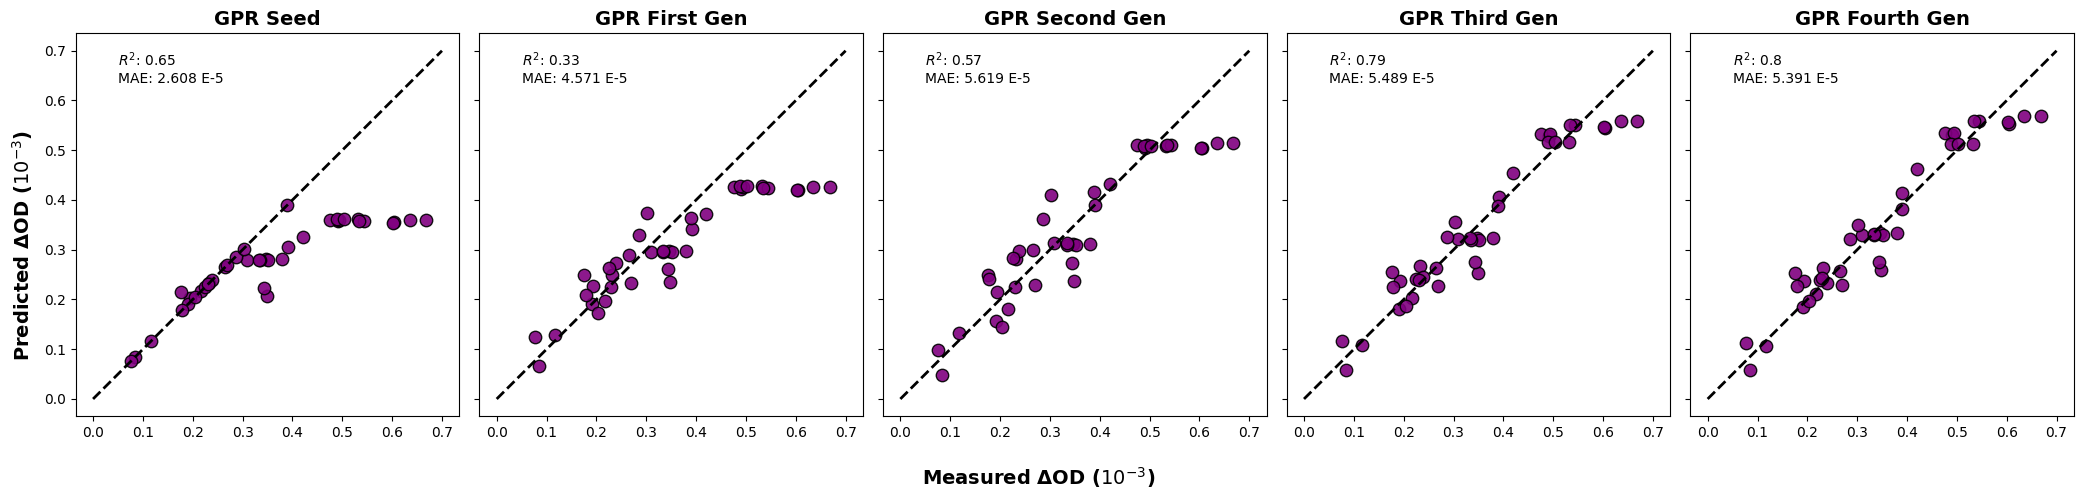

In [35]:
from sklearn.metrics import r2_score as sklearn_r2_score
kernel = DotProduct() + RBF(length_scale=1.0) + WhiteKernel(0.001, noise_level_bounds=(1e-5, 1))

# Model names can be mapped if desired (optional)
model_names = {
    1: "Seed",
    2: "First Gen",
    3: "Second Gen",
    4: "Third Gen",
    5: "Fourth Gen",
    6: "Fifth Gen",
    7: "Sixth Gen",
    8: "Seventh Gen",
    9: "Eighth Gen",
    10: "Ninth Gen",
    11: "Tenth Gen",
    # Keep going if desired
}

# List to store models
gp_models = []
cv_results = {}
n_folds = 4
kf = KFold(n_splits=n_folds, shuffle=True, random_state=38)
full_iterations = {}
scaler = StandardScaler()

# Loop through all iterations in data_bank
for iteration in sorted(var.data_bank_example['Iteration'].dropna().unique()):
    subset = var.data_bank_example[(var.data_bank_example['Iteration'] <= iteration) & (var.data_bank_example['Status'] == True)]
    if subset.empty:
        continue

    absorbance_slope = subset['Slope'] * 1000
    compositions = subset.drop(columns=['Slope', 'Status','Iteration'])
    compositions, absorbance_slope = shuffle(compositions, absorbance_slope, random_state=42)

    subset_iteration = var.data_bank_example[(var.data_bank_example['Iteration'] == iteration) & (var.data_bank_example['Status'] == True)]
    absorbance_slope_iteration = subset_iteration['Slope'] * 1000
    full_iterations[model_names.get(iteration, f'Iter {iteration}')] = absorbance_slope_iteration

    model = GaussianProcessRegressor(kernel=kernel)
    model.fit(compositions, absorbance_slope)

    gp_models.append((iteration, model))

    compositions1 = scaler.fit_transform(compositions)
    absorbance_slope1 = absorbance_slope / 1000
    # Initialize lists to store R² scores for each fold
    r2_scores = []
    mse_scores = []
    mae_scores = []

    # Perform cross-validation manually
    for train_index, test_index in kf.split(compositions1):
        X_train, X_test = compositions1[train_index], compositions1[test_index]
        y_train, y_test = absorbance_slope1.iloc[train_index], absorbance_slope1.iloc[test_index]

        # Model training
        gp_model = GaussianProcessRegressor(kernel=kernel)
        gp_model.fit(X_train, y_train)

        # Predict on the test set
        y_pred = gp_model.predict(X_test)

        # Calculate R², MSE, and MAE for this fold
        r2_scores.append(sklearn_r2_score(y_test, y_pred))
        mse_scores.append(-np.mean((y_test - y_pred) ** 2))  # Negative MSE for consistency
        mae_scores.append(-np.mean(np.abs(y_test - y_pred)))  # Negative MAE for consistency

    # Store the mean of the scores across all folds
    cv_results[model_names.get(iteration, f'Iter {iteration}')] = {
        'R2': np.mean(r2_scores),
        'MSE': np.mean(mse_scores),
        'MAE': np.mean(mae_scores)
    }

# Convert to DataFrame for easy viewing
cv_df = pd.DataFrame.from_dict(cv_results, orient='index')

# Plot model performance per generation
num_plots = len(gp_models)
fig, axes = plt.subplots(1, num_plots, figsize=(21, 5), sharex=True, sharey=True)

for i, (iteration, gp_model) in enumerate(gp_models[:num_plots]):
    # Predict
    predicted_vmax, predicted_std = gp_model.predict(compositions, return_std=True)

    # Plot
    ax = axes[i]
    ax.scatter(absorbance_slope, predicted_vmax, s=80, color='#800080', edgecolors='black', alpha=0.9)
    ax.plot([0, 0.7], [0, 0.7], 'k--', linewidth=2)

    title = model_names.get(iteration, f'Iter {iteration}')
    ax.set_title(f'GPR {title}', fontsize=14, fontweight='bold')

    legend_text = f"$R^2$: {round(cv_results[title]['R2'], 2)}\nMAE: {round(cv_results[title]['MAE']*-100000, 3)} E-5"
    ax.text(0.05, 0.7, legend_text, fontsize=10, ha='left', va='top', backgroundcolor='white')

# Set global labels
fig.supxlabel('Measured ΔOD ($10^{-3}$)', fontsize=14, fontweight='bold')
fig.supylabel('Predicted ΔOD ($10^{-3}$)', fontsize=14, fontweight='bold',x=0.01)

plt.tight_layout()
plt.show()

#### Gen-on-Gen/R^2 Improvement
This visualization technique utilizes a box-and-whisker plot to portray each generation, and how the target feature varies. It is supplemented with an R<sup>2</sup> plot showing how the ML model's performance varies depending on the type of information being fed into the ML model.

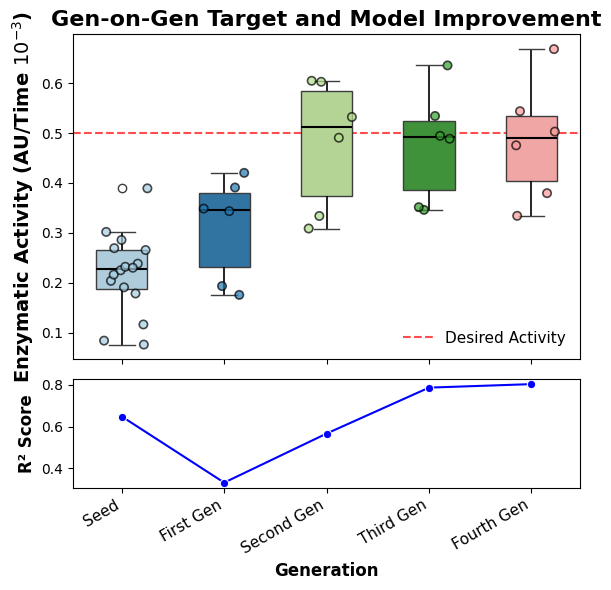

In [36]:
# Create two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Prepare DataFrame for box plot
df_box = pd.DataFrame({key: pd.Series(value) for key, value in full_iterations.items()})
df_strip = pd.DataFrame([(key, value) for key, values in full_iterations.items() for value in values],
                        columns=["Generation", "Slope"])

palette = sns.color_palette("Paired", n_colors=len(full_iterations))

# Box plot + strip plot on top subplot
ax1.axhline(var.desired_activity * 1000, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label="Desired Activity")

sns.boxplot(
    data=df_box,
    width=0.5,
    showcaps=True,
    palette=palette,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black', 'linewidth': 1.2},
    ax=ax1
)

sns.stripplot(
    data=df_strip,
    x="Generation",
    y="Slope",
    jitter=0.25,
    palette=palette,
    alpha=0.7,
    size=6,
    edgecolor="black",
    linewidth=1.2,
    ax=ax1
)

ax1.set_ylabel(r'Enzymatic Activity (AU/Time $10^{-3}$)', fontsize=14, fontweight='bold')
ax1.set_title(r'Gen-on-Gen Target and Model Improvement', fontsize=16, fontweight='bold')
ax1.legend(loc='lower right', frameon=False, fontsize=11)

# R² Score line plot on bottom subplot
sns.lineplot(data=cv_df["R2"], marker='o', linestyle='-', color='b', ax=ax2)
ax2.set_ylabel("R² Score", fontsize=12, fontweight='bold')
ax2.set_xlabel("Generation", fontsize=12, fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha="right", fontsize=11)


# Adjust spacing
plt.tight_layout()
plt.show()

#### Shapely Additive Explanations (SHAP)
SHAP is a framework for interpreting machine learning model's predictions based on shapley values, a concept derived from game theory. This attributes the contribution of each player (feature) to the total outcome of a game (model prediction).

  0%|          | 0/40 [00:00<?, ?it/s]

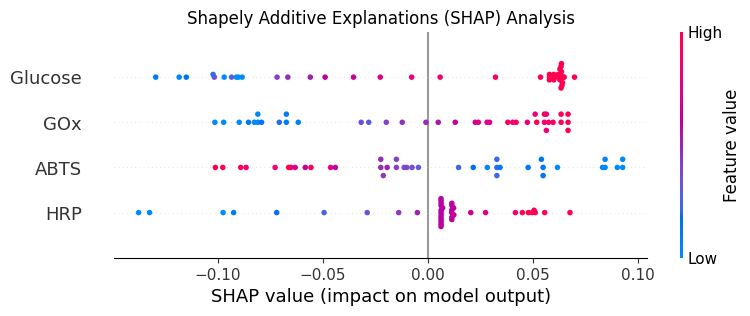

In [37]:
# Isolate all compositions used to train model, and select the most recent model
compositions_shap = var.data_bank_example.loc[var.data_bank_example['Status'] == True].drop(labels=['Slope','Status','Iteration'],axis=1)

iteration,gp_shap = gp_models[-1]

# Initialize kernel explainer
explainer = shap.KernelExplainer(gp_shap.predict, compositions_shap)

# Calculate SHAP values
shap_values = explainer.shap_values(compositions_shap)

# Generate the summary plot
shap.summary_plot(shap_values, compositions_shap, show=False)
plt.title("Shapely Additive Explanations (SHAP) Analysis")
plt.show()

## Summary
In this section, we showed how one could apply some of the skills discussed in the previous notebook for the purposes of creating a workflow for self-driven laboratories. This was done by brief explanations and discussions of the script guiding our custom-built liquid handler. We first identified specific preliminary information that was used throughout the section. We show a representation of the user interface that one can use to obtain a design space based on their inputs. We explored the building blocks that make up the Design-Build-Test-Learn workflow, and how we stitch these blocks together to create a seamless automated experimentation device. Finally, we discussed some of the visualization methods that can aid in the human understanding of what the DBTL loop learns about the design space.  